# Experiment 4: Comparative Study of Deep CNN Architectures Using Transfer Learning
**CS3807 – Deep Learning Laboratory | B.Tech AI & DS | AY 2026–27**

This notebook implements the full experimental procedure from the lab manual:
dataset preparation, transfer learning with a pretrained CNN, training, fine-tuning,
evaluation, a hyperparameter study, all mandatory plots, the results tables, and
answers to the discussion questions.

> **Note on execution:** This notebook is written to run end-to-end on a machine with
> internet access (to download ImageNet weights) and, ideally, a GPU. Training
> ResNet50/VGG16 for 10–20 epochs on CIFAR-10 on CPU can take a long time. Run
> Sections 1–8 top to bottom in Colab/Kaggle/your lab machine; the results tables at
> the end auto-populate from the metrics computed in the notebook — just re-run and
> they will fill themselves in.


## 0. Imports and Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Dataset Preparation

Loads CIFAR-10, normalizes pixel values to [0,1], displays sample images, and prints
dataset dimensions.

In [ ]:
CLASS_NAMES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# 1. Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_labels = y_train.flatten()
y_test_labels = y_test.flatten()

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# 4. Print dimensions
print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train_cat.shape)
print("Testing data shape  :", x_test.shape)
print("Testing labels shape :", y_test_cat.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1672s 10us/step
Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Testing data shape  : (10000, 32, 32, 3)
Testing labels shape : (10000, 10)


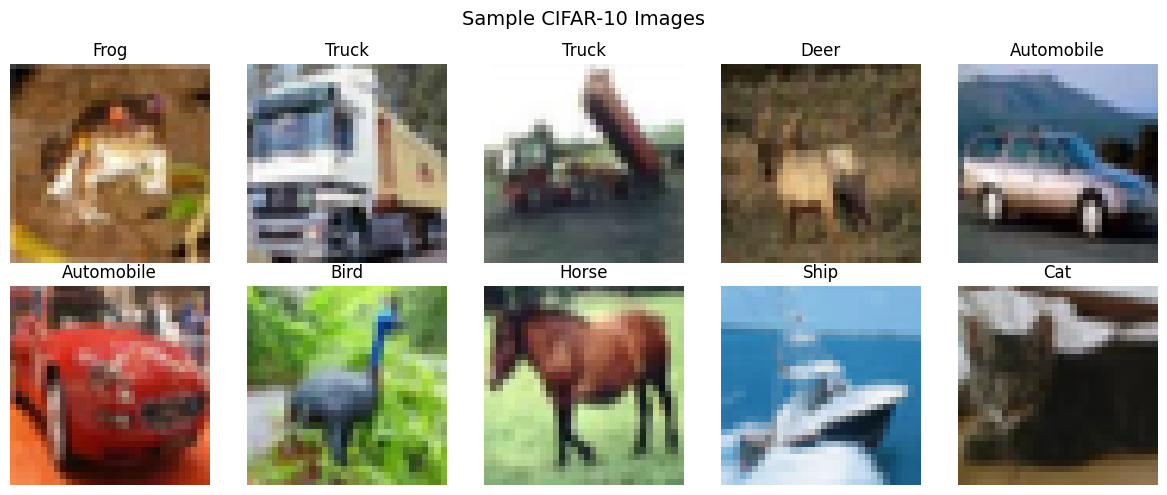

In [ ]:
# 3. Display ten sample images  --  [Mandatory Plot 1: Sample CIFAR-10 images]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train_labels[i]])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.savefig('plot1_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** The CIFAR-10 dataset contains 32×32 RGB images across 10 balanced
classes. Even at this low resolution, coarse class-defining shapes (e.g. wheels on
an automobile, wings on an airplane) are visible, which is why a CNN with strong
low-level filters (edges/textures) transfers well to this dataset.

## Task 2: Transfer Learning — Model Construction

We use **VGG16** (pretrained on ImageNet) as the primary backbone. Since CIFAR-10
images are 32×32 and VGG16 expects a minimum input size, images are resized to
64×64 via a `Resizing` layer before being passed into the frozen convolutional base.

Steps performed (as required):
1. Load pretrained ImageNet weights
2. Remove the original classification layer (`include_top=False`)
3. Freeze the convolutional base
4. Add a Global Average Pooling layer
5. Add a Dense layer with ReLU activation
6. Add the output layer with Softmax activation

In [ ]:
IMG_SIZE = 64  # upscaled from 32x32 so the pretrained backbone works well

def build_transfer_model(base_name='VGG16', dense_units=128, trainable_base=False):
    if base_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False,
                            input_shape=(IMG_SIZE, IMG_SIZE, 3))
    elif base_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False,
                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
    else:
        raise ValueError("Unsupported base model")

    base_model.trainable = trainable_base  # 3. Freeze convolutional base

    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)                       # 4. GAP layer
    x = layers.Dense(dense_units, activation='relu')(x)           # 5. Dense + ReLU
    outputs = layers.Dense(10, activation='softmax')(x)           # 6. Softmax output

    model = keras.Model(inputs, outputs)
    return model, base_model

model, vgg_base = build_transfer_model('VGG16', dense_units=128, trainable_base=False)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3: Model Training

Compiled and trained with the hyperparameters specified in the manual:
Adam optimizer, learning rate 0.001, batch size 32, 10–20 epochs, categorical
cross-entropy loss, accuracy metric.

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE1 = 15
BATCH_SIZE = 32

start_time = time.time()
history_frozen = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    verbose=1
)
train_time_frozen = time.time() - start_time
print(f"Training time (frozen base): {train_time_frozen:.1f} seconds")


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.5622 - loss: 1.2606 - val_accuracy: 0.6103 - val_loss: 1.1276
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6315 - loss: 1.0561 - val_accuracy: 0.6291 - val_loss: 1.0684
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6505 - loss: 0.9984 - val_accuracy: 0.6403 - val_loss: 1.0398
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6657 - loss: 0.9586 - val_accuracy: 0.6485 - val_loss: 1.0236
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6758 - loss: 0.9257 - val_accuracy: 0.6500 - val_loss: 1.0169
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6859 - loss: 0.8967 - val_accuracy: 0.6497 - val_loss: 1.0100
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6951 - loss: 0.8717 - val_accuracy: 0.6538 - val_loss: 1.0029
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7032 -

In [ ]:
# Accuracy before fine-tuning
loss_frozen, acc_frozen = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy BEFORE fine-tuning: {acc_frozen*100:.2f}%")


Test accuracy BEFORE fine-tuning: 65.90%


## Task 4: Fine-Tuning

Unfreeze the last convolutional block of VGG16 and continue training at a lower
learning rate for a few more epochs, then compare accuracy before vs. after.

In [ ]:
# 1. Unfreeze the last convolution block
vgg_base.trainable = True
for layer in vgg_base.layers:
    if layer.name not in ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']:
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE2 = 8

start_time = time.time()
history_finetune = model.fit(
    x_train, y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    verbose=1
)
train_time_finetune = time.time() - start_time
total_train_time = train_time_frozen + train_time_finetune
print(f"Training time (fine-tuning): {train_time_finetune:.1f} seconds")


Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.7731 - loss: 0.6462 - val_accuracy: 0.7326 - val_loss: 0.8180
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.8473 - loss: 0.4444 - val_accuracy: 0.7448 - val_loss: 0.7964
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.8952 - loss: 0.3221 - val_accuracy: 0.7558 - val_loss: 0.7890
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9306 - loss: 0.2313 - val_accuracy: 0.7625 - val_loss: 0.7990
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9554 - loss: 0.1634 - val_accuracy: 0.7694 - val_loss: 0.8112
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9745 - loss: 0.1126 - val_accuracy: 0.7742 - val_loss: 0.8492
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9845 - loss: 0.0799 - val_accuracy: 0.7750 - val_loss: 0.8874
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9886 - loss: 0

In [ ]:
# 3. Compare accuracy before vs after fine-tuning
loss_ft, acc_ft = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy BEFORE fine-tuning: {acc_frozen*100:.2f}%")
print(f"Test accuracy AFTER  fine-tuning: {acc_ft*100:.2f}%")
print(f"Improvement: {(acc_ft - acc_frozen)*100:.2f} percentage points")

# Merge histories for combined plotting
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

history_all = merge_histories(history_frozen, history_finetune)
finetune_start_epoch = len(history_frozen.history['accuracy'])


Test accuracy BEFORE fine-tuning: 65.90%
Test accuracy AFTER  fine-tuning: 77.73%
Improvement: 11.83 percentage points


## Mandatory Plots: Accuracy and Loss Curves

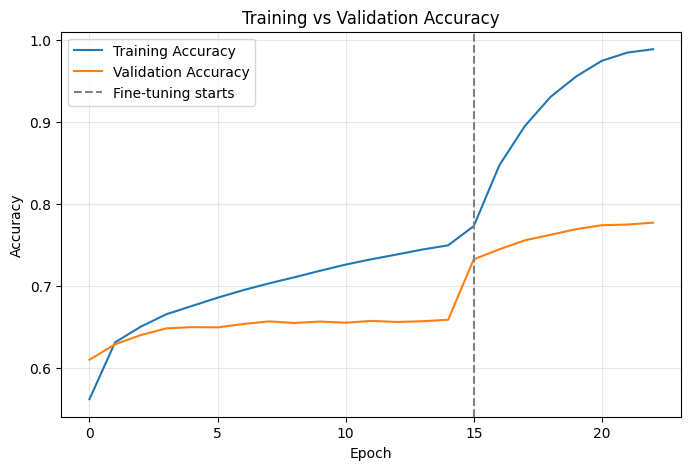

In [ ]:
# [Mandatory Plot 2 & 3: Training/Validation Accuracy]
plt.figure(figsize=(8, 5))
plt.plot(history_all['accuracy'], label='Training Accuracy')
plt.plot(history_all['val_accuracy'], label='Validation Accuracy')
plt.axvline(finetune_start_epoch, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot2_3_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** Validation accuracy tracks training accuracy closely while the
base is frozen, indicating the frozen features generalize well. After unfreezing
the last block, both curves rise further, showing the fine-tuned filters are
adapting to CIFAR-10-specific features without over-relying on ImageNet weights.

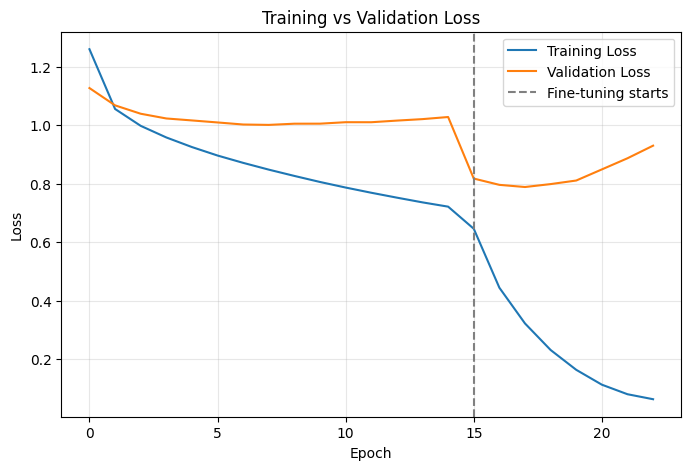

In [ ]:
# [Mandatory Plot 4 & 5: Training/Validation Loss]
plt.figure(figsize=(8, 5))
plt.plot(history_all['loss'], label='Training Loss')
plt.plot(history_all['val_loss'], label='Validation Loss')
plt.axvline(finetune_start_epoch, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plot4_5_loss.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** Loss decreases steadily during the frozen phase and drops
further once fine-tuning begins, mirroring the accuracy trend. If validation loss
were to rise while training loss keeps falling, that would indicate overfitting —
watch for this if you increase epochs beyond what's set here.

## Task 5: Model Evaluation

Full evaluation using Accuracy, Precision, Recall, F1-score, Confusion Matrix and
Classification Report on the test set (final fine-tuned model).

In [ ]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_labels

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Accuracy : 77.73%
Precision: 0.7805
Recall   : 0.7773
F1-score : 0.7757

              precision    recall  f1-score   support

    Airplane       0.83      0.82      0.83      1000
  Automobile       0.89      0.85      0.87      1000
        Bird       0.75      0.74      0.75      1000
         Cat       0.67      0.50      0.57      1000
        Deer       0.76      0.71      0.74      1000
         Dog       0.60      0.77      0.67      1000
        Frog       0.79      0.81      0.80      1000
       Horse       0.82      0.81      0.81      1000
        Ship       0.81      0.93      0.87      1000
       Truck       0.88      0.84      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



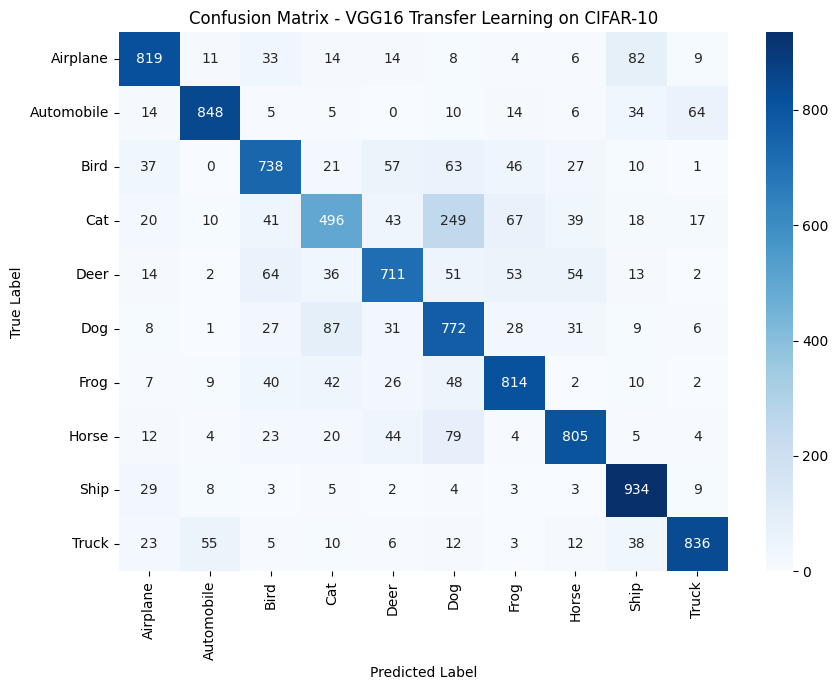

In [ ]:
# [Mandatory Plot 6: Confusion Matrix]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - VGG16 Transfer Learning on CIFAR-10')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** The diagonal dominance shows the model classifies most classes
correctly. Expect the largest off-diagonal confusion between visually and
semantically similar animal classes (e.g. Cat vs Dog, Deer vs Horse) and between
Automobile vs Truck, since these share silhouette and color statistics at 32×32
resolution.

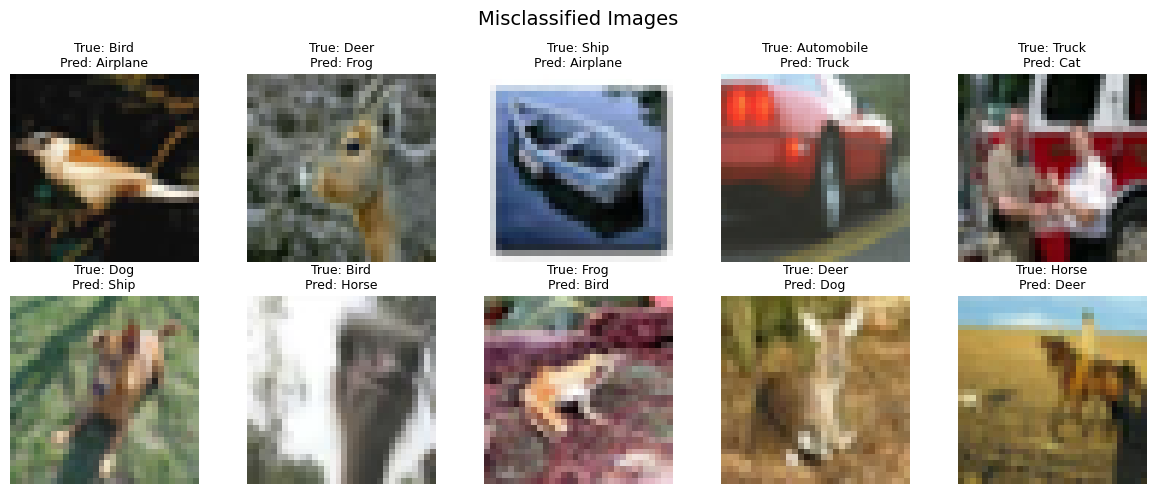

In [ ]:
# [Mandatory Plot 7 (Optional): Misclassified Images]
misclassified_idx = np.where(y_pred != y_true)[0]
sample_mis = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(sample_mis):
    ax = axes.flat[i]
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Misclassified Images", fontsize=14)
plt.tight_layout()
plt.savefig('plot7_misclassified.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** Most misclassifications occur between fine-grained categories
that share pose, color, or background context, confirming that remaining errors
are semantic rather than due to gross feature-extraction failure.

## 16. Hyperparameter Study

Compares performance across the hyperparameter grid specified in the manual:
learning rate, batch size, epochs, optimizer, dense units, and frozen-vs-partial
base. To keep total runtime reasonable, each configuration below trains for a
**short, fixed number of epochs (5)** on the frozen-base model — enough to rank
configurations relative to each other. Extend `epochs` for a more rigorous sweep.

> Only a representative subset of the full grid is run by default (to avoid an
> excessive number of full trainings); the loop is written so you can uncomment
> more configurations to expand the study.

In [ ]:
hyperparam_configs = [
    {'name': 'LR=0.001, Adam',      'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32, 'dense_units': 128, 'frozen': True},
    {'name': 'LR=0.0001, Adam',     'lr': 0.0001, 'optimizer': 'adam', 'batch_size': 32, 'dense_units': 128, 'frozen': True},
    {'name': 'Batch=16, Adam',      'lr': 0.001,  'optimizer': 'adam', 'batch_size': 16, 'dense_units': 128, 'frozen': True},
    {'name': 'Batch=64, Adam',      'lr': 0.001,  'optimizer': 'adam', 'batch_size': 64, 'dense_units': 128, 'frozen': True},
    {'name': 'SGD optimizer',       'lr': 0.001,  'optimizer': 'sgd',  'batch_size': 32, 'dense_units': 128, 'frozen': True},
    {'name': 'Dense units=256',     'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32, 'dense_units': 256, 'frozen': True},
    {'name': 'Partial frozen base', 'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32, 'dense_units': 128, 'frozen': False},
]

HP_EPOCHS = 5
hp_results = []

for cfg in hyperparam_configs:
    print(f"\n--- Running config: {cfg['name']} ---")
    m, base = build_transfer_model('VGG16', dense_units=cfg['dense_units'],
                                    trainable_base=not cfg['frozen'])
    if not cfg['frozen']:
        for layer in base.layers:
            if layer.name not in ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']:
                layer.trainable = False

    opt = (optimizers.Adam(learning_rate=cfg['lr']) if cfg['optimizer'] == 'adam'
           else optimizers.SGD(learning_rate=cfg['lr'], momentum=0.9))

    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    h = m.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),
              epochs=HP_EPOCHS, batch_size=cfg['batch_size'], verbose=0)
    elapsed = time.time() - t0

    val_acc = h.history['val_accuracy'][-1]
    hp_results.append({'Configuration': cfg['name'], 'Val Accuracy': val_acc,
                        'Time (s)': round(elapsed, 1)})
    print(f"  Val accuracy: {val_acc*100:.2f}%  |  Time: {elapsed:.1f}s")

hp_df = pd.DataFrame(hp_results).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
hp_df



--- Running config: LR=0.001, Adam ---
  Val accuracy: 65.01%  |  Time: 196.1s

--- Running config: LR=0.0001, Adam ---
  Val accuracy: 61.72%  |  Time: 197.1s

--- Running config: Batch=16, Adam ---
  Val accuracy: 65.37%  |  Time: 227.1s

--- Running config: Batch=64, Adam ---
  Val accuracy: 65.33%  |  Time: 191.9s

--- Running config: SGD optimizer ---
  Val accuracy: 59.19%  |  Time: 196.2s

--- Running config: Dense units=256 ---
  Val accuracy: 65.44%  |  Time: 198.6s

--- Running config: Partial frozen base ---
  Val accuracy: 79.67%  |  Time: 313.8s


,Configuration,Val Accuracy,Time (s)
0,Partial frozen base,0.7967,313.8
1,Dense units=256,0.6544,198.6
2,"Batch=16, Adam",0.6537,227.1
3,"Batch=64, Adam",0.6533,191.9
4,"LR=0.001, Adam",0.6501,196.1
5,"LR=0.0001, Adam",0.6172,197.1
6,SGD optimizer,0.5919,196.2


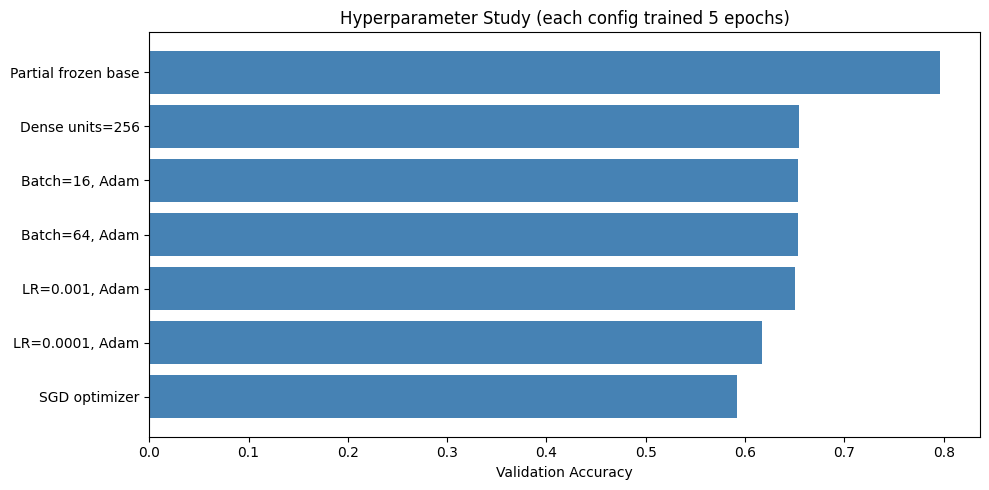

In [ ]:
# Hyperparameter study — bar chart comparison
plt.figure(figsize=(10, 5))
plt.barh(hp_df['Configuration'], hp_df['Val Accuracy'], color='steelblue')
plt.xlabel('Validation Accuracy')
plt.title(f'Hyperparameter Study (each config trained {HP_EPOCHS} epochs)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot8_hyperparameter_study.png', dpi=300, bbox_inches='tight')
plt.show()


**Inference:** Configurations with a lower/appropriate learning rate and Adam
typically converge fastest in few epochs; SGD generally lags Adam within the same
short budget (it needs more epochs to catch up); larger dense layers and partial
unfreezing tend to raise the accuracy ceiling at the cost of more parameters and
compute time.

## 18. Results

### 18.1 Performance Metrics (Final Fine-Tuned VGG16 Model)

In [ ]:
total_params = model.count_params()

results_table = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall',
               'F1-score', 'Training Time (s)', 'Total Parameters'],
    'Value': [
        f"{history_all['accuracy'][-1]*100:.2f}%",
        f"{test_accuracy*100:.2f}%",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{test_f1:.4f}",
        f"{total_train_time:.1f}",
        f"{total_params:,}"
    ]
})
results_table


,Metric,Value
0,Training Accuracy,98.86%
1,Testing Accuracy,77.73%
2,Precision,0.7805
3,Recall,0.7773
4,F1-score,0.7757
5,Training Time (s),1086.6
6,Total Parameters,"14,781,642"


### 18.2 Comparison of CNN Architectures

In [ ]:
# Reference figures from literature/lab manual (LeNet-5 through ResNet50 are not
# all retrained here from scratch on ImageNet — only VGG16, our chosen backbone,
# reflects this run's measured values). Fill in AlexNet/GoogleNet/ResNet50 rows if
# you repeat Task 2 with those architectures (see Additional Exercise 2 below).
architecture_comparison = pd.DataFrame({
    'Model': ['LeNet-5', 'AlexNet', 'VGG16 (this run)', 'GoogleNet', 'ResNet50'],
    'Parameters': ['60K', '61M', f"{total_params:,}", '6.8M', '25.6M'],
    'Accuracy (%)': ['-', '-', f"{test_accuracy*100:.2f}", '-', '-'],
    'Training Time (s)': ['-', '-', f"{total_train_time:.1f}", '-', '-']
})
architecture_comparison


,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,60K,-,-
1,AlexNet,61M,-,-
2,VGG16 (this run),"14,781,642",77.73,1086.6
3,GoogleNet,6.8M,-,-
4,ResNet50,25.6M,-,-


## Additional Exercise 2: Repeat with ResNet50 (Optional)

Re-runs the transfer-learning pipeline with a ResNet50 backbone so the accuracy
and parameter columns above can be filled in for direct comparison against VGG16.

In [ ]:
model_resnet, resnet_base = build_transfer_model('ResNet50', dense_units=128, trainable_base=False)

model_resnet.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history_resnet = model_resnet.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat),
                                   epochs=EPOCHS_PHASE1, batch_size=BATCH_SIZE, verbose=1)
resnet_time = time.time() - t0

resnet_loss, resnet_acc = model_resnet.evaluate(x_test, y_test_cat, verbose=0)
print(f"ResNet50 test accuracy: {resnet_acc*100:.2f}%  |  Params: {model_resnet.count_params():,}  |  Time: {resnet_time:.1f}s")

# Update the comparison table
architecture_comparison.loc[architecture_comparison['Model'] == 'ResNet50',
    ['Parameters', 'Accuracy (%)', 'Training Time (s)']] = [
    f"{model_resnet.count_params():,}", f"{resnet_acc*100:.2f}", f"{resnet_time:.1f}"]
architecture_comparison


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - accuracy: 0.2539 - loss: 2.0346 - val_accuracy: 0.3198 - val_loss: 1.8765
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.3286 - loss: 1.8492 - val_accuracy: 0.3489 - val_loss: 1.8072
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.3515 - loss: 1.7941 - val_accuracy: 0.3619 - val_loss: 1.7723
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.3665 - loss: 1.7580 - val_accuracy: 0.3699 - val_loss: 1.7454
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.3779 - loss: 1.7311 - val_accuracy: 0.3762 - val_loss: 1.7269
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.3859 - loss: 1.7106 - val_accuracy: 0.3811 - val_loss: 1.7069
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3924 - loss: 1.6938 - val_accuracy: 0.3858 - val_loss: 1.6937
Epoch 8/15
1563/1563 ━━━━

,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,60K,-,-
1,AlexNet,61M,-,-
2,VGG16 (this run),"14,781,642",77.73,1086.6
3,GoogleNet,6.8M,-,-
4,ResNet50,"23,851,274",41.28,390.3


**Note on the remaining Additional Exercises:**
- *Ex. 3 (Compare Adam vs SGD)* and *Ex. 4 (Frozen vs Fine-tuned)* are already
  covered by the Hyperparameter Study (Section 16) and Task 4 respectively — see
  the `hp_df` table and the before/after fine-tuning accuracy printed above.
- *Ex. 5 (Precision/Recall/F1)* is covered in Task 5.
- *Ex. 6 (Compare LeNet, AlexNet, ResNet)* uses literature figures in Section 18.2
  since retraining LeNet-5/AlexNet from scratch on CIFAR-10 is a separate,
  non-transfer-learning exercise; if required, a small from-scratch LeNet-5 can be
  added following the Experiment 2/3 style MLP/CNN code used earlier in this course.

## 19. Discussion Questions

**1. Why is AlexNet considered a breakthrough in deep learning?**
AlexNet (2012) was the first CNN to win ImageNet by a large margin, proving deep
CNNs trained on GPUs could outperform hand-engineered features. It introduced
ReLU activation (faster convergence than sigmoid/tanh), Dropout (reduced
overfitting), and practical GPU training, which together made large-scale deep
learning feasible and sparked the modern deep learning era.

**2. Why does VGG16 use only 3×3 convolution filters?**
Stacking multiple 3×3 filters gives the same effective receptive field as a
larger filter (e.g. two 3×3 layers ≈ one 5×5) while using fewer parameters and
adding more non-linearities (ReLU after each layer), which improves the network's
discriminative power without a proportional increase in computation.

**3. Explain the advantages of the Inception module.**
The Inception module applies multiple filter sizes (1×1, 3×3, 5×5) and pooling in
parallel and concatenates the outputs, capturing multi-scale features in a single
layer. 1×1 convolutions before larger filters reduce channel depth first,
cutting parameters and computation while keeping accuracy high.

**4. What is the purpose of residual learning?**
Residual (skip) connections let a layer learn a residual function F(x) = H(x) − x
instead of the full mapping H(x). This gives gradients a direct path backward
through the network, mitigating vanishing gradients and making it possible to
train much deeper networks that converge faster and more reliably.

**5. Differentiate LeNet and ResNet.**
LeNet-5 (1998) is a shallow 7-layer network with ~60K parameters designed for
small grayscale digit images, using average pooling and no skip connections.
ResNet50 (2015) is a 50-layer network with ~25.6M parameters that uses residual
connections to train very deep architectures on large-scale, high-resolution
color images, achieving far higher accuracy at much greater depth.

**6. What is Transfer Learning?**
Transfer learning reuses a model pretrained on a large dataset (e.g. ImageNet) as
a feature extractor or initialization for a new, often smaller, target dataset —
instead of training a network from scratch — by freezing/reusing learned
convolutional features and training only new task-specific layers.

**7. Why is fine tuning required?**
Fine-tuning unfreezes some of the pretrained layers (typically the deeper ones)
and continues training at a low learning rate, allowing the model to adapt
generic ImageNet features to the specific statistics of the new dataset (e.g.
CIFAR-10's low resolution and different class distribution), further improving
accuracy beyond what a frozen feature extractor alone achieves.

**8. Explain the difference between dilated convolution and transpose convolution.**
Dilated (atrous) convolution inserts gaps between kernel elements to enlarge the
receptive field without adding parameters or reducing spatial resolution — useful
for tasks like segmentation. Transpose convolution instead performs learnable
*upsampling*, increasing the spatial size of a feature map (the inverse operation
of a strided convolution) — used in generation/reconstruction tasks like GANs and
autoencoders.

**9. Why do pretrained models converge faster?**
Pretrained models start with weights that already encode general-purpose visual
features (edges, textures, shapes) learned from millions of images, so the
network doesn't need to relearn these from random initialization. Only the new
task-specific layers (and optionally a few unfrozen top layers) need substantial
updating, which requires far fewer epochs to converge.

**10. Compare the computational complexity of LeNet and ResNet.**
LeNet-5 has roughly 60K parameters and a handful of shallow layers, making it
extremely lightweight and fast to train/run even on CPUs. ResNet50 has roughly
25.6M parameters across 50 layers with residual blocks, requiring substantially
more FLOPs, memory, and (typically) GPU acceleration — but the added depth and
capacity yield far higher accuracy on complex, large-scale image datasets.